# Solve MaxSAT using Fire Opal
**Apply Fire Opal's built-in QAOA solver to weighted and unweighted MaxSAT instances**

MaxSAT problems are a fundamental class of combinatorial optimization problems, where the goal is to find an assignment of Boolean variables that maximizes the number of satisfied clauses in a Boolean formula. They arise in a wide range of real-world applications, including software verification, artificial intelligence, and industrial scheduling and planning. A key example is our [recent work on rail scheduling](https://q-ctrl.com/case-study/accelerating-the-schedule-for-quantum-enhanced-rail), where the problem of determining optimal train arrival and departure times at stations can be formulated as a MaxSAT instance.

[Fire Opal's built-in Quantum Approximate Optimization Algorithm (QAOA) solver](https://docs.q-ctrl.com/fire-opal/execute/run-algorithms/solve-optimization-problems/fire-opal-qaoa-solver) can deliver solutions to both unweighted and weighted MaxSAT problem instances using quantum hardware.

Recently, [Q-CTRL published results](https://arxiv.org/abs/2406.01743) demonstrating Fire Opal's capability to correctly solve classically nontrivial quadratic unconstrained binary optimization (QUBO) problems at world-leading scale. Here, we show that Fire Opal can also be applied to satisfiability problems corresponding to more complex higher-order unconstrained binary optimization (HUBO) problems. This application note covers the following:

- An introduction to MaxSAT
- An introduction to QAOA
- Execution of Fire Opal's QAOA solver for a 40-variable weighted 3-MaxSAT instance
- Evaluation of the QAOA solver performance

## 1 Introduction

## 1.1 Introduction to MaxSAT

A MaxSAT instance consists of a set of Boolean variables, each of which can be assigned a value of true or false, combined into logical clauses. In the unweighted version of MaxSAT, all clauses are treated equally, and the objective is to find an assignment that maximizes the number of satisfied clauses. In the weighted variant, each clause is assigned a weight reflecting its relative importance, and the objective becomes maximizing the total weight of satisfied clauses.

The MaxSAT problem is well suited to approximate and heuristic optimization methods since no polynomial-time algorithm is known for solving general instances exactly. A promising direction for this is near-term quantum computing, which has the potential to efficiently generate high-quality approximate solutions for MaxSAT instances that are computationally challenging for classical approaches.

## 1.2 Introduction to QAOA

QAOA is an algorithm often applied to combinatorial optimization problems, which involve finding an optimal object out of a finite set of objects. Such problems are relevant in many fields, such as portfolio optimization, supply chain optimization, optimal networking and scheduling, transportation routing, and more. Many combinatorial optimizations of interest fall under the NP-hard complexity class, meaning that there are no known polynomial-time solutions.

QAOA is one algorithm within the broader class of variational quantum algorithms (VQAs), which use classical optimization techniques to train a parameterized quantum circuit. Combining the power of both classical and quantum computation, VQAs are a promising method to achieve quantum advantage on NISQ devices and will likely remain relevant even in the age of fault-tolerant quantum computing.

Typically when implementing the QAOA, one must:
- Define cost and mixer Hamiltonians
- Construct circuits for the cost and mixer layers
- Choose parameters
- Prepare the initial state
- Implement a classical parameter optimizer

Adding to the challenge, most implementations of QAOA fail when executed on real hardware, either converging on the wrong solution or never converging at all.

Fire Opal’s QAOA solver alleviates the complexity of running QAOA algorithms by providing an easy-to-use function that consistently returns the correct answer. It converges quickly and enables the full QAOA implementation on problem sizes [greater than achievable with other commercial QAOA methods](https://arxiv.org/abs/2406.01743).

## 2. Imports and initializations

The following section sets up the necessary imports, credentials, and helper functions.

In [ ]:
import fireopal as fo
import matplotlib.pyplot as plt
import numpy as np
from pysat.examples.rc2 import RC2
from pysat.formula import WCNF
import qctrlvisualizer as qv
from sympy import Mul, Poly, symarray

plt.style.use(qv.get_qctrl_style())

### 2.1 Credentials and backend

We have developed this notebook to run on an IBM backend. To run it, you need an [IBM Quantum account](https://quantum.cloud.ibm.com/). Set up Fire Opal with your IBM account information and choose a backend.

In [ ]:
# The Fire Opal QAOA solver needs an IBM Cloud account with access to IBM Sessions execution mode,
# which is not available to Open Plan users. To use the solver, you must have a paid IBM Quantum plan.
# See here for details: https://quantum.cloud.ibm.com/docs/en/guides/execution-modes#session-mode
# and here for plans: https://www.ibm.com/quantum/products#access-plans
token = "YOUR_IBM_CLOUD_API_KEY"
instance = "YOUR_IBM_CRN"

credentials = fo.credentials.make_credentials_for_ibm_cloud(
    token=token, instance=instance
)

In [ ]:
# Enter your desired IBM backend here.
backend_name = "your_desired_backend"

### 2.2 Helper functions

Define functions that are used to set up the MaxSAT problem instance and analyze the results.

In [ ]:
def maxsat_to_cost(maxsat: WCNF) -> Poly:
    """
    Convert a MaxSAT instance in WCNF format to a cost polynomial.
    """
    # For unweighted MaxSAT, set uniform weight to 1
    if len(set(maxsat.wght)) == 1 and maxsat.wght[0] != 1:
        maxsat.wght = [1] * len(maxsat.wght)

    variables = symarray("x", maxsat.nv)
    cost = 0
    # Assume all clauses are saved as soft clauses (no hard clauses); iterate through them and add the corresponding terms to the cost polynomial
    for weight, clause in zip(maxsat.wght, maxsat.soft):
        cost += weight * Mul(
            *[
                variables[abs(lit) - 1] if lit < 0 else (1 - variables[abs(lit) - 1])
                for lit in clause
            ]
        )
    return Poly(cost, *variables)


def solve_classically(maxsat: WCNF) -> tuple[str, float]:
    """
    Solve the MaxSAT problem classically using the RC2 solver.
    """
    with RC2(maxsat) as rc2:
        model = rc2.compute()
        # Calculate the bitstring representing the classical solution
        result = "".join("1" if var > 0 else "0" for var in model)
        solution_cost = rc2.cost
    return result, solution_cost


def get_cost_distribution(
    distribution: dict[str, int], cost: Poly, index_map: dict = None
) -> tuple[np.ndarray, np.ndarray]:
    """
    Given a bitstring count distribution and a cost polynomial, compute the costs and relative probabilities.
    """
    shot_count = sum(distribution.values())
    variables = cost.gens
    costs = []
    probabilities = []
    # Calculate the cost and probability for each bitstring
    for bitstring, count in distribution.items():
        if index_map:
            costs.append(
                cost.subs({var: bitstring[index_map[str(var)]] for var in variables})
            )
        else:
            costs.append(cost.subs(zip(cost.gens, bitstring)))
        probabilities.append(count / shot_count)
    return np.array(costs), np.array(probabilities)


def generate_random_bitstrings(
    length: int, num_bitstrings: int, rng_seed: int = 0
) -> list[str]:
    """
    Generate a random sampling of bitstrings.
    """
    # Initialize the random number generator with a seed for reproducibility
    rng = np.random.default_rng(seed=rng_seed)
    # Generate random bitstrings
    random_array = rng.integers(0, 2, size=(num_bitstrings, length))
    bitstrings = ["".join(row.astype(str)) for row in random_array]
    return bitstrings


def analyze_maxsat_results(
    distribution: dict[str, int], bitstring: str, cost: Poly, index_map: dict
) -> None:
    """
    Analyze and visualize results from a MaxSAT execution using Fire Opal.
    """
    solution_cost = cost.subs(
        {var: bitstring[index_map[str(var)]] for var in cost.gens}
    )
    print(f"The best solution found by Fire Opal has cost {solution_cost}.")

    # Number of variables
    qubit_count = len(bitstring)
    # Total number of bitstrings (shots)
    shot_count = sum(distribution.values())

    # Get cost distribution from the results
    costs, probs = get_cost_distribution(distribution, cost, index_map)
    # Generate random bitstrings and get their cost distribution
    random_bitstrings = generate_random_bitstrings(qubit_count, shot_count)
    random_probs = np.ones(shot_count) / shot_count
    random_costs = np.asarray(
        [cost.subs(zip(cost.gens, bitstring)) for bitstring in random_bitstrings]
    )

    # Plot cost histograms
    _, ax = plt.subplots(1, 1)
    ax.hist(
        [costs, random_costs],
        np.arange(0, 100, 1),
        weights=[probs, random_probs],
        label=["Fire Opal QAOA solver", "Random Sampling"],
        color=[qv.QCTRL_STYLE_COLORS[0], qv.QCTRL_STYLE_COLORS[1]],
    )
    ax.set_xlabel("Solution cost")
    ax.set_ylabel("Probability")
    ax.legend()

## 3. Example problem setup

As an example, we load a pre-generated random MaxSAT instance with 40 variables and 60 clauses. Each clause involves exactly 3 variables and is assigned a random weight between 1 and 10 to reflect its relative priority. This example instance can be replaced with a user-defined MaxSAT problem. After loading the instance, we compute the corresponding cost polynomial.

In [5]:
# Enter the MaxSAT problem to solve in weighted conjunctive normal form (WCNF)
maxsat = WCNF(from_file="resources/maxsat.wcnf")
cost = maxsat_to_cost(maxsat)

## 4. Running the algorithm

Run Fire Opal's QAOA solver for the cost polynomial representing the MaxSAT problem.

In [ ]:
fire_opal_job = fo.solve_qaoa(cost, credentials, backend_name)

The following command extracts the Fire Opal result as soon as the calculation has finished. To check the current job status, you can run `fire_opal_job.status()`.

In [ ]:
fire_opal_solution = fire_opal_job.result()

## 5. Analyze Fire Opal output

To establish a performance baseline, we compare the cost distribution of Fire Opal's QAOA solver output to that of randomly sampled bitstrings. This comparison is particularly relevant, as a naive QAOA implementation using standard Qiskit compiler settings typically yields results that are indistinguishable from random sampling at the considered problem scale. To ensure a fair comparison, the number of random samples matches the number of shots used for the QAOA circuits.

The best solution found by Fire Opal has cost 0.


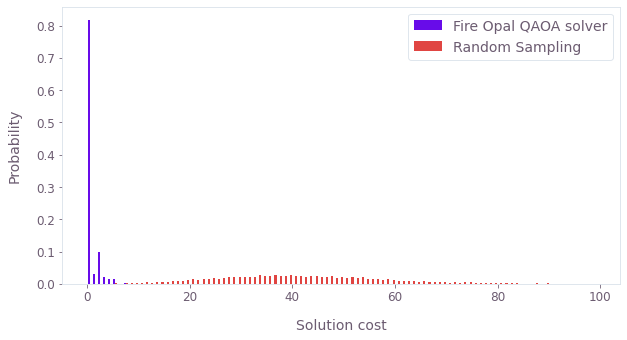

In [7]:
analyze_maxsat_results(
    fire_opal_solution["final_bitstring_distribution"],
    fire_opal_solution["solution_bitstring"],
    cost,
    fire_opal_solution["variables_to_bitstring_index_map"],
)

Fire Opal clearly outperforms random sampling, as lower solution costs correspond to fewer violated clauses. The solver consistently returns high-quality solutions, with the best solution having a cost of 0, indicating no violated clauses.

Since the example problem is still solvable with classical methods, it is possible to assess the accuracy of the solution obtained with Fire Opal.

In [8]:
optimal_solution, optimal_cost = solve_classically(maxsat)
print(f"Optimal classical solution has cost {optimal_cost}.")

Optimal classical solution has cost 0.


The solution returned by Fire Opal matches the optimal classical solution with no violated clauses.

You have successfully leveraged Fire Opal's QAOA Solver to solve a challenging MaxSAT problem with quantum hardware. For a deeper dive into what sets Fire Opal's QAOA Solver apart and its efficacy in finding accurate solutions at utility scales, explore the topic on [Fire Opal's QAOA Solver](https://docs.q-ctrl.com/fire-opal/execute/run-algorithms/solve-optimization-problems/fire-opal-qaoa-solver).

The following package versions were used to produce this notebook.

In [9]:
fo.print_package_versions()

| Package               | Version |
| --------------------- | ------- |
| Python                | 3.11.11 |
| matplotlib            | 3.10.1  |
| networkx              | 2.8.8   |
| numpy                 | 1.26.4  |
| sympy                 | 1.13.3  |
| fire-opal             | 8.4.1   |
| qctrl-visualizer      | 8.0.2   |
| qctrl-workflow-client | 5.5.0   |
